<a href="https://colab.research.google.com/github/techasit239/DADS7202_PigPicture/blob/main/FreshCheck_Phase0_Foundation_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FreshCheck Deep Lab — Phase 0: Foundation Setup

**Course:** DADS 7202 Deep Learning · NIDA
**Project:** FreshCheck Deep Lab — Material-aware pork freshness classification
**Authors:** Jirapong (M) · Techasit (E) · Yingphan (D)

---

## Phase 0 ทำอะไร?

Phase 0 = **เตรียมข้อมูลและพื้นฐาน** ก่อนเทรนโมเดลใน Phase 1+

| ขั้น | งาน | Output |
|---|---|---|
| 0.1 | Setup (Drive + GPU + seed) | folders พร้อม |
| 0.2 | Download Kaggle dataset (2,266 รูป) | `data/kaggle_meat/` |
| 0.3 | EDA + filter pork samples | print stats |
| 0.4 | **Group-aware split 80/20** (anti-leakage) | `splits/kaggle_train.csv`, `splits/kaggle_val.csv` |
| 0.5 | Thai filename parser (helper สำหรับ Phase 3) | `configs/thai_filename_parser.py` |

## ก่อนเริ่ม — เตรียม 2 อย่าง

1. **`kaggle.json`** — ไปที่ Kaggle → Settings → API → Create New Token
2. **โฟลเดอร์ `FreshCheck/`** ที่ root ของ Google Drive (จะถูกสร้างอัตโนมัติถ้ายังไม่มี)

**Runtime:** ตั้งเป็น `T4 GPU` (Runtime → Change runtime type)


## 0.1 — Setup Environment

ขั้นนี้:
- Mount Google Drive
- ตั้ง random seed = 42 (เพื่อให้รันซ้ำได้ผลเหมือนเดิม)
- เช็ค GPU
- สร้าง folder structure


In [ ]:
# 0.1.1 — Imports + random seed
import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Python OK | NumPy {np.__version__} | PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[!] GPU ไม่พบ — ไปที่ Runtime → Change runtime type → T4 GPU")


Python OK | NumPy 2.0.2 | PyTorch 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# 0.1.2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Project root อยู่ใน Drive เพื่อให้ผลลัพธ์ persist หลังจบ session
PROJECT_ROOT = '/content/drive/MyDrive/FreshCheck'

# สร้างโครงสร้างโฟลเดอร์ของโปรเจกต์
SUBDIRS = ['data', 'splits', 'configs', 'models', 'models/classification', 'logs']
for sub in SUBDIRS:
    os.makedirs(f'{PROJECT_ROOT}/{sub}', exist_ok=True)

print(f"[OK] Project root: {PROJECT_ROOT}")
for sub in SUBDIRS:
    print(f"  └── {sub}/")


Mounted at /content/drive
[OK] Project root: /content/drive/MyDrive/FreshCheck
  └── data/
  └── splits/
  └── configs/
  └── models/
  └── models/classification/
  └── logs/


## 0.2 — Download Kaggle Dataset

Dataset: **Meat Freshness Image Dataset** (Vinayak Shanawad) — 2,266 รูป × 3 classes (FRESH / HALF_FRESH / SPOILED)
อ้างอิงใน Proposal เป็น [17]

### ขั้นตอน
1. รัน cell ด้านล่าง — มันจะเปิดกล่องให้ upload ไฟล์
2. กด **Choose Files** → เลือก `kaggle.json` ที่ดาวน์โหลดมาจาก Kaggle
3. รอดาวน์โหลด + แตก zip (ประมาณ 1-2 นาที)

ถ้ารันซ้ำครั้งที่ 2 — มันจะข้ามการดาวน์โหลดถ้าเจอข้อมูลแล้ว


In [ ]:
# 0.2.1 — Install kaggle CLI + upload kaggle.json
!pip install -q kaggle

from google.colab import files

# ถ้ายังไม่มี kaggle.json ใน Drive ให้ upload
KAGGLE_JSON_DRIVE = f'{PROJECT_ROOT}/configs/kaggle.json'

if os.path.exists(KAGGLE_JSON_DRIVE):
    print(f"[OK] เจอ kaggle.json เก่าใน Drive — ใช้ของเดิม")
    !mkdir -p ~/.kaggle
    !cp "$KAGGLE_JSON_DRIVE" ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
else:
    print("กรุณา upload ไฟล์ kaggle.json (Kaggle → Settings → API → Create New Token)")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    # backup เก็บไว้ใน Drive ครั้งหน้าไม่ต้อง upload ซ้ำ
    !cp ~/.kaggle/kaggle.json "$KAGGLE_JSON_DRIVE"
    print(f"[OK] เก็บ backup ไว้ที่ {KAGGLE_JSON_DRIVE}")


กรุณา upload ไฟล์ kaggle.json (Kaggle → Settings → API → Create New Token)


Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
cp: cannot stat '/root/.kaggle/kaggle.json': No such file or directory
[OK] เก็บ backup ไว้ที่ /content/drive/MyDrive/FreshCheck/configs/kaggle.json


In [ ]:
# 0.2.2 — Download + unzip
import zipfile

DATA_DIR = f'{PROJECT_ROOT}/data/kaggle_meat'
ZIP_PATH = '/content/meat-freshness-image-dataset.zip'

# ตรวจว่า extract แล้วหรือยัง (ดูจากจำนวนไฟล์ image)
def count_images(path):
    if not os.path.exists(path):
        return 0
    n = 0
    for root, _, fnames in os.walk(path):
        n += sum(1 for f in fnames if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    return n

n_existing = count_images(DATA_DIR)
if n_existing > 100:
    print(f"[OK] เจอข้อมูลเก่า {n_existing} รูป — ข้ามการดาวน์โหลด")
else:
    print("กำลังดาวน์โหลดจาก Kaggle ...")
    !cd /content && kaggle datasets download -d vinayakshanawad/meat-freshness-image-dataset

    print("กำลังแตก zip ไปที่ Drive (อาจช้าหน่อยเพราะเขียนลง Drive) ...")
    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)

    print(f"[OK] แตกเสร็จ — ตอนนี้มี {count_images(DATA_DIR)} รูป")


[OK] เจอข้อมูลเก่า 2266 รูป — ข้ามการดาวน์โหลด


In [ ]:
# 0.2.3 — Inspect dataset structure
import subprocess

print("โครงสร้างโฟลเดอร์ใน dataset:\n")
result = subprocess.run(['find', DATA_DIR, '-maxdepth', '3', '-type', 'd'],
                        capture_output=True, text=True)
for line in result.stdout.strip().split('\n'):
    # แสดงเป็น tree view คร่าวๆ
    depth = line.replace(DATA_DIR, '').count('/')
    name = line.split('/')[-1] if line else '(root)'
    print(f"{'  ' * depth}{name}/")


โครงสร้างโฟลเดอร์ใน dataset:

kaggle_meat/
  Meat Freshness.v1-new-dataset.multiclass/
    train/
    valid/


## 0.3 — Exploratory Data Analysis

นับจำนวนรูปแต่ละ class และดู filename pattern เพื่อเอาไปออกแบบ piece_id ในขั้น 0.4


In [ ]:
# 0.3.1 — Build dataframe of all images
#
# Kaggle Meat Freshness dataset (Roboflow export) folder structure:
#   data/kaggle_meat/
#   ├── train/<CLASS>-<ID>-_JPG.rf.<HASH>.jpg
#   └── valid/<CLASS>-<ID>-_JPG.rf.<HASH>.jpg
#
# → folder = original Kaggle split (train/valid) ไม่ใช่ class
# → class จริงอยู่ใน filename prefix: FRESH-, HALF-FRESH-, SPOILED-
import pandas as pd
from pathlib import Path

def extract_class_from_filename(filename):
    """
    Parse class label from filename prefix.
    Order matters: HALF-FRESH ต้องเช็คก่อน FRESH
    (เพราะ HALF-FRESH ก็มี 'FRESH' อยู่ในนั้น)
    """
    name = filename.upper()
    if name.startswith('HALF-FRESH') or name.startswith('HALFFRESH'):
        return 'HALF_FRESH'
    elif name.startswith('FRESH'):
        return 'FRESH'
    elif name.startswith('SPOILED'):
        return 'SPOILED'
    else:
        return 'UNKNOWN'


data_path = Path(DATA_DIR)
records = []
for img_path in data_path.rglob('*'):
    if img_path.is_file() and img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        original_split = img_path.parent.name   # 'train' or 'valid'/'test' — keep for ref
        cls = extract_class_from_filename(img_path.name)
        records.append({
            'filename': img_path.name,
            'path': str(img_path),
            'class': cls,
            'kaggle_split': original_split,
            'size_kb': round(img_path.stat().st_size / 1024, 1),
        })

df = pd.DataFrame(records)
print(f"Total images: {len(df)}\n")
print("Class distribution (parsed from filename):")
print(df['class'].value_counts().to_string())
print(f"\nKaggle original split:")
print(df['kaggle_split'].value_counts().to_string())
print(f"\nClass × Kaggle split crosstab:")
print(pd.crosstab(df['class'], df['kaggle_split']))

# Sanity check
n_unknown = (df['class'] == 'UNKNOWN').sum()
if n_unknown > 0:
    print(f"\n[!] WARNING: {n_unknown} files ไม่ match class pattern — ตรวจ filename ดู:")
    print(df[df['class'] == 'UNKNOWN']['filename'].head().tolist())
else:
    print(f"\n[OK] ทุกไฟล์ parse class ได้")


Total images: 2266

Class distribution (parsed from filename):
class
FRESH         853
HALF_FRESH    789
SPOILED       624

Kaggle original split:
kaggle_split
train    1815
valid     451

Class × Kaggle split crosstab:
kaggle_split  train  valid
class                     
FRESH           675    178
HALF_FRESH      630    159
SPOILED         510    114

[OK] ทุกไฟล์ parse class ได้


In [ ]:
# 0.3.2 — Inspect filename patterns
print("ตัวอย่าง 15 filename แรกของแต่ละ class:\n")
for cls in sorted(df['class'].unique()):
    print(f"=== {cls} ===")
    sample = df[df['class'] == cls]['filename'].head(15).tolist()
    for f in sample:
        print(f"  {f}")
    print()


ตัวอย่าง 15 filename แรกของแต่ละ class:

=== FRESH ===
  FRESH-1-_JPG.rf.65663691924ca0aede3884b863267c98.jpg
  FRESH-100-_JPG.rf.65e835ab6a2890785aade192d1e19549.jpg
  FRESH-1000-_JPG.rf.d0f18a5c4075b50beeb7ee99036d491d.jpg
  FRESH-1003-_JPG.rf.b410c33a04a1fba90032a9086d191d6d.jpg
  FRESH-1005-_JPG.rf.404839308dfdce0228de77bf7458513a.jpg
  FRESH-1009-_JPG.rf.1c4c304a072d95160d6ec26f0191344e.jpg
  FRESH-101-_JPG.rf.4c18cd9fd197ac72fa9dd68fcd00502f.jpg
  FRESH-102-_JPG.rf.97c72ce29de7a165b8b59fab7bd7c735.jpg
  FRESH-103-_JPG.rf.8f12ec3bf550794dd0b16325bdc69740.jpg
  FRESH-106-_JPG.rf.e52846e129a95100c4442337b570eea3.jpg
  FRESH-107-_JPG.rf.ac43eaf2ed93ae57f4a26cfb1b2a71dd.jpg
  FRESH-108-_JPG.rf.8109de5fe39e80699ac3e5e8f8ff771a.jpg
  FRESH-109-_JPG.rf.424a8b05df3bfc9703256510ee15c2ed.jpg
  FRESH-110-_JPG.rf.c328c2d34b8ff7c5c20c6c1b145d4507.jpg
  FRESH-111-_JPG.rf.fcac599f24f667bbd45a3fb2aaaaabfb.jpg

=== HALF_FRESH ===
  HALF-FRESH-248-_JPG.rf.24d2260207ff2d27d49af4739cd875ba.jpg
  HALF

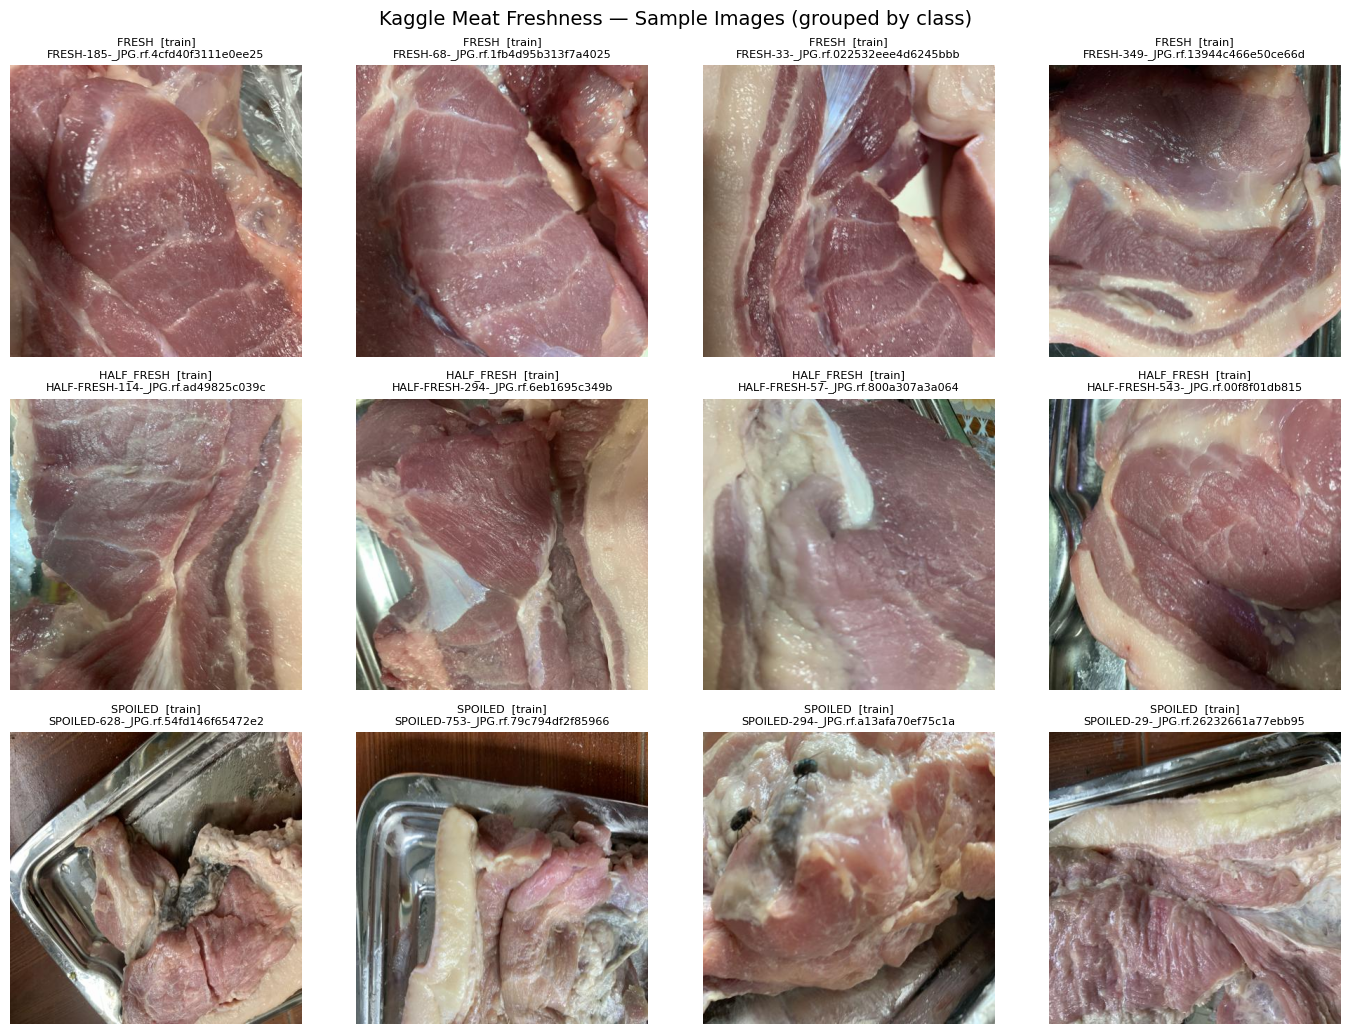

In [ ]:
# 0.3.3 — Show sample images (subplot size matches number of classes)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

classes = sorted([c for c in df['class'].unique() if c != 'UNKNOWN'])
n_rows = len(classes)
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
# axes อาจเป็น 1-D ถ้า n_rows = 1 → handle ให้เป็น 2-D เสมอ
if n_rows == 1:
    axes = axes.reshape(1, -1)

for row, cls in enumerate(classes):
    subset_pool = df[df['class'] == cls]
    subset = subset_pool.sample(min(n_cols, len(subset_pool)), random_state=SEED)
    for col, (_, r) in enumerate(subset.iterrows()):
        ax = axes[row, col]
        try:
            img = mpimg.imread(r['path'])
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center')
        ax.set_title(f"{cls}  [{r['kaggle_split']}]\n{r['filename'][:35]}", fontsize=8)
        ax.axis('off')

plt.suptitle("Kaggle Meat Freshness — Sample Images (grouped by class)", fontsize=14)
plt.tight_layout()
plt.show()


## 0.4 — Group-aware Split (Anti-leakage)

### ทำไมต้อง group-aware (ไม่ random ธรรมดา)?

อาจารย์เตือนใน Comment ว่า: ก้อนเนื้อชิ้นเดียวกันที่ถูกถ่ายซ้ำในช่วงเวลาต่างกัน **ต้องอยู่ split เดียวกัน** ไม่งั้นจะเกิด data leak — model จะ "เคยเห็น" ก้อนนั้นใน train แล้ว เห็นซ้ำใน val → accuracy สูงเกินจริง

### กลยุทธ์ — สำหรับ Kaggle dataset (Roboflow-augmented)

Filename pattern: `<CLASS>-<ID>-_JPG.rf.<HASH>.jpg`
- `FRESH-867-_JPG.rf.74be74a17676.jpg` → base image = `FRESH-867`
- `FRESH-867-_JPG.rf.aabbcc.jpg` → base image **เดียวกัน** = `FRESH-867`

ดังนั้น `piece_id = "<CLASS>-<ID>"` — augmented copies ของ base image เดียวกันจะอยู่ split เดียวกัน

ขั้นตอน:
1. ดึง `piece_id` = `<CLASS>-<ID>` จาก filename prefix
2. ใช้ `GroupShuffleSplit` ของ scikit-learn (group=piece_id)
3. **Assertion**: ตรวจว่า train ∩ val = ∅ ก่อนเซฟ


In [ ]:
# 0.4.1 — Extract piece_id from filename
#
# Roboflow filename: <CLASS>-<ID>-_<ORIGEXT>.rf.<HASH>.<EXT>
# เช่น  FRESH-867-_JPG.rf.74be74a17676.jpg → piece = FRESH-867
#       HALF-FRESH-801-_JPG.rf.5bc8f03.jpg → piece = HALF-FRESH-801
# Augmented copies ของรูปเดียวกัน share <CLASS>-<ID> เดียวกัน
import re

PIECE_PATTERN = re.compile(r'^([A-Z\-]+\d+)')


def extract_piece_id(filename):
    """
    Return piece_id = <CLASS>-<ID> for Roboflow-style filenames.
    Fallback: filename stem (1 piece per image).
    """
    stem = Path(filename).stem
    m = PIECE_PATTERN.match(stem.upper())
    if m:
        return m.group(1)
    return stem


df['piece_id'] = df['filename'].apply(extract_piece_id)

n_total = len(df)
n_pieces = df['piece_id'].nunique()
avg_per_piece = n_total / n_pieces

print(f"Total images:  {n_total}")
print(f"Unique pieces: {n_pieces}")
print(f"Avg images/piece: {avg_per_piece:.2f}")

if avg_per_piece > 1.5:
    print(f"\n[!] เจอ augmented copies ({avg_per_piece:.1f} รูป/piece avg)")
    print(f"    → group-aware split สำคัญมาก — ป้องกัน augmentation leak")
else:
    print(f"\n[OK] ส่วนใหญ่ 1 รูป/piece — น่าจะไม่มี augmentation")

print(f"\nTop 10 pieces by # augmented copies:")
print(df['piece_id'].value_counts().head(10).to_string())


Total images:  2266
Unique pieces: 2266
Avg images/piece: 1.00

[OK] ส่วนใหญ่ 1 รูป/piece — น่าจะไม่มี augmentation

Top 10 pieces by # augmented copies:
piece_id
SPOILED-996       1
HALF-FRESH-248    1
HALF-FRESH-25     1
HALF-FRESH-250    1
HALF-FRESH-252    1
HALF-FRESH-253    1
HALF-FRESH-254    1
HALF-FRESH-255    1
HALF-FRESH-256    1
HALF-FRESH-257    1


In [ ]:
# 0.4.2 — Group-aware 80/20 split
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, val_idx = next(gss.split(df, groups=df['piece_id']))

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
val_df = df.iloc[val_idx].copy().reset_index(drop=True)

# === Anti-leakage assertion ===
train_pieces = set(train_df['piece_id'])
val_pieces = set(val_df['piece_id'])
overlap = train_pieces & val_pieces

assert len(overlap) == 0, f"LEAK DETECTED! Overlapping pieces: {overlap}"
print(f"[OK] Anti-leakage verified — 0 overlapping pieces\n")

print(f"Train: {len(train_df):>5} images ({len(train_pieces):>5} pieces)")
print(f"Val:   {len(val_df):>5} images ({len(val_pieces):>5} pieces)")
print(f"Ratio: {len(val_df)/(len(train_df)+len(val_df))*100:.1f}% val\n")

print("Train class distribution:")
print(train_df['class'].value_counts().to_string())
print("\nVal class distribution:")
print(val_df['class'].value_counts().to_string())


[OK] Anti-leakage verified — 0 overlapping pieces

Train:  1812 images ( 1812 pieces)
Val:     454 images (  454 pieces)
Ratio: 20.0% val

Train class distribution:
class
FRESH         672
HALF_FRESH    624
SPOILED       516

Val class distribution:
class
FRESH         181
HALF_FRESH    165
SPOILED       108


In [ ]:
# 0.4.3 — Save splits to CSV
TRAIN_CSV = f'{PROJECT_ROOT}/splits/kaggle_train.csv'
VAL_CSV = f'{PROJECT_ROOT}/splits/kaggle_val.csv'

train_df.to_csv(TRAIN_CSV, index=False)
val_df.to_csv(VAL_CSV, index=False)

print(f"[OK] Saved:")
print(f"  {TRAIN_CSV} ({len(train_df)} rows)")
print(f"  {VAL_CSV}   ({len(val_df)} rows)")
print(f"\nColumns: {list(train_df.columns)}")


[OK] Saved:
  /content/drive/MyDrive/FreshCheck/splits/kaggle_train.csv (1812 rows)
  /content/drive/MyDrive/FreshCheck/splits/kaggle_val.csv   (454 rows)

Columns: ['filename', 'path', 'class', 'kaggle_split', 'size_kb', 'piece_id']


## 0.5 — Thai Filename Parser (สำหรับ Phase 3)

สร้างฟังก์ชัน parse filename ของรูปไทยที่ทีมเก็บมาเอง ตาม Master Filename Format

```
YYYYMMDD_HHMM_classCode_sourceType_pieceID.ext

ตัวอย่าง: 20260518_1000_FR_PK_P01.jpg
                          ^^^
                          piece_id (group key สำหรับ anti-leakage)

classCode:  FR=Fresh, HF=Half-Fresh, SP=Spoiled
sourceType: PK=Packaged (ซูเปอร์), UP=Unpackaged (ตลาดสด)
```

ขั้นนี้สร้าง module file ที่ Phase 3 จะ `import` ไปใช้


In [ ]:
# 0.5.1 — Write Thai filename parser module
parser_code = '''"""
Thai filename parser for FreshCheck Deep Lab
Format: YYYYMMDD_HHMM_classCode_sourceType_pieceID.ext
Example: 20260518_1000_FR_PK_P01.jpg
"""
import re
from pathlib import Path
from datetime import datetime

CLASS_MAP = {"FR": "Fresh", "HF": "Half-Fresh", "SP": "Spoiled"}
SOURCE_MAP = {"PK": "Packaged", "UP": "Unpackaged"}

FILENAME_PATTERN = re.compile(
    r"^(\d{8})_(\d{4})_(FR|HF|SP)_(PK|UP)_(P\d+)$"
)


def parse_thai_filename(filename):
    """
    Parse FreshCheck Thai filename → dict.

    Returns: {datetime, class, class_code, source, source_code, piece_id, valid}
    Raises ValueError if filename does not match expected format.
    """
    stem = Path(filename).stem
    m = FILENAME_PATTERN.match(stem)
    if not m:
        raise ValueError(
            f"Invalid filename: '{filename}'. "
            f"Expected: YYYYMMDD_HHMM_classCode_sourceType_pieceID.ext"
        )
    date_str, time_str, class_code, source_code, piece_id = m.groups()
    dt = datetime.strptime(date_str + time_str, "%Y%m%d%H%M")
    return {
        "datetime": dt,
        "class": CLASS_MAP[class_code],
        "class_code": class_code,
        "source": SOURCE_MAP[source_code],
        "source_code": source_code,
        "piece_id": piece_id,
        "valid": True,
    }


def is_valid_thai_filename(filename):
    """Return True if filename matches the FreshCheck format."""
    try:
        parse_thai_filename(filename)
        return True
    except ValueError:
        return False


if __name__ == "__main__":
    test_cases = [
        ("20260518_1000_FR_PK_P01.jpg", True),
        ("20260520_1430_HF_UP_P05.jpg", True),
        ("20260522_0900_SP_PK_P12.png", True),
        ("IMG_1234.jpg", False),
    ]
    for name, expected in test_cases:
        ok = is_valid_thai_filename(name)
        flag = "[OK]" if ok == expected else "[FAIL]"
        print(f"{flag} {name} -> valid={ok} (expected={expected})")
'''

parser_path = f'{PROJECT_ROOT}/configs/thai_filename_parser.py'
with open(parser_path, 'w', encoding='utf-8') as f:
    f.write(parser_code)

print(f"[OK] Saved Thai filename parser to:\n  {parser_path}")


<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_18136/2037303647.py:15: SyntaxWarning: invalid escape sequence '\d'
  r"^(\d{8})_(\d{4})_(FR|HF|SP)_(PK|UP)_(P\d+)$"


[OK] Saved Thai filename parser to:
  /content/drive/MyDrive/FreshCheck/configs/thai_filename_parser.py


In [ ]:
# 0.5.2 — Test the parser
import importlib.util
spec = importlib.util.spec_from_file_location(
    "thai_filename_parser",
    f'{PROJECT_ROOT}/configs/thai_filename_parser.py'
)
tfp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tfp)

# Test cases
test_files = [
    '20260518_1000_FR_PK_P01.jpg',  # Fresh, Packaged, piece 01
    '20260520_1430_HF_UP_P05.jpg',  # Half-Fresh, Unpackaged, piece 05
    '20260522_0900_SP_PK_P12.png',  # Spoiled, Packaged, piece 12
    'IMG_1234.jpg',                  # Invalid → should raise
]

for name in test_files:
    try:
        parsed = tfp.parse_thai_filename(name)
        dt = parsed['datetime'].strftime('%Y-%m-%d %H:%M')
        print(f"[OK]   {name}")
        print(f"       → {parsed['class']} ({parsed['class_code']}) | "
              f"{parsed['source']} ({parsed['source_code']}) | "
              f"piece={parsed['piece_id']} | time={dt}")
    except ValueError as e:
        print(f"[FAIL] {name}: {str(e)[:60]}...")


[OK]   20260518_1000_FR_PK_P01.jpg
       → Fresh (FR) | Packaged (PK) | piece=P01 | time=2026-05-18 10:00
[OK]   20260520_1430_HF_UP_P05.jpg
       → Half-Fresh (HF) | Unpackaged (UP) | piece=P05 | time=2026-05-20 14:30
[OK]   20260522_0900_SP_PK_P12.png
       → Spoiled (SP) | Packaged (PK) | piece=P12 | time=2026-05-22 09:00
[FAIL] IMG_1234.jpg: Invalid filename: 'IMG_1234.jpg'. Expected: YYYYMMDD_HHMM_cl...


## 0.6 — Phase 0 Summary

ตรวจสอบ output ทั้งหมดของ Phase 0 ว่าครบและพร้อมให้ Phase 1 ใช้ต่อ


In [ ]:
# 0.6.1 — Verify outputs
print("=" * 60)
print("PHASE 0 — Foundation Setup Complete")
print("=" * 60)
print(f"\nProject root: {PROJECT_ROOT}\n")

expected_files = [
    ('splits/kaggle_train.csv', 'train split'),
    ('splits/kaggle_val.csv', 'val split'),
    ('configs/thai_filename_parser.py', 'Thai filename parser'),
]

all_ok = True
for rel_path, desc in expected_files:
    full = f'{PROJECT_ROOT}/{rel_path}'
    if os.path.exists(full):
        size_kb = os.path.getsize(full) / 1024
        print(f"[OK]   {rel_path:<45} ({size_kb:>7.1f} KB) — {desc}")
    else:
        print(f"[FAIL] {rel_path:<45} (missing!) — {desc}")
        all_ok = False

# Dataset summary
n_imgs = sum(1 for _ in Path(DATA_DIR).rglob('*')
             if _.is_file() and _.suffix.lower() in ['.jpg', '.jpeg', '.png'])
print(f"\nDataset images: {n_imgs}")
print(f"Train images:   {len(train_df)}")
print(f"Val images:     {len(val_df)}")

if all_ok:
    print("\n[OK] Phase 0 พร้อมแล้ว — ไป Phase 1 (EfficientNet-B0) ได้เลย")
else:
    print("\n[!] มีไฟล์ขาดหาย — เช็คอีกครั้งก่อนไป Phase 1")


PHASE 0 — Foundation Setup Complete

Project root: /content/drive/MyDrive/FreshCheck

[OK]   splits/kaggle_train.csv                       (  431.6 KB) — train split
[OK]   splits/kaggle_val.csv                         (  108.2 KB) — val split
[OK]   configs/thai_filename_parser.py               (    1.9 KB) — Thai filename parser

Dataset images: 2266
Train images:   1812
Val images:     454

[OK] Phase 0 พร้อมแล้ว — ไป Phase 1 (EfficientNet-B0) ได้เลย
